# Pryzm Pricing Engine — v1 Notebook

**Goal:** prove a real, defensible price-recommendation engine on real Scherzinger data before any backend wiring.

**Outline** (14 sections):
1. Setup + data load
2. EDA — win-rate, price spread, churn distribution, cost trajectory
3. Fit win-probability
4. Fit churn-response
5. Wire forecasts (cost + volume)
6. LTV — 24mo discounted contribution
7. Score function demo (3 SKUs with CI ribbons)
8. Optimiser demo (p*, breakeven, drivers, constraint flags)
9. Monte Carlo confidence band
10. 2025 walk-forward backtest
11. Acceptance-gate report
12. 2026 forward recommendations
13. Sensitivity & failure analysis
14. Promotion checklist

**Reference:** `docs/whitepaper/pryzm_pricing_methodology.tex` for the full methodology. `docs/superpowers/specs/2026-05-19-pricing-engine-design.md` for the internal design spec.

## 1. Setup + data load

In [1]:
import sys, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from lib import (
    data_loader, win_prob, churn_response, cost_demand,
    ltv, scorer, monte_carlo, backtest, metrics,
)

np.random.seed(17)
plt.rcParams.update({
    'figure.figsize': (8, 4), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 9, 'axes.titlesize': 10,
})

TRAIN_END = pd.Timestamp('2024-12-31')
EVAL_START = pd.Timestamp('2025-01-01')
EVAL_END = pd.Timestamp('2025-12-31')

bundle_train = data_loader.load_all(as_of=TRAIN_END)
bundle_full = data_loader.load_all()
global_win_rate = float(bundle_train.quotes['is_won'].mean())

print(f'train quotes: {len(bundle_train.quotes):>5d}   invoices: {len(bundle_train.invoices):>5d}')
print(f'full  quotes: {len(bundle_full.quotes):>5d}   invoices: {len(bundle_full.invoices):>5d}')
print(f'global win-rate (train): {global_win_rate:.3f}')

train quotes:  3313   invoices:  4157
full  quotes:  4539   invoices:  5565
global win-rate (train): 0.366


## 2. EDA — distributions

Quick visual sanity checks so we know what the engine is working with before we trust any output.

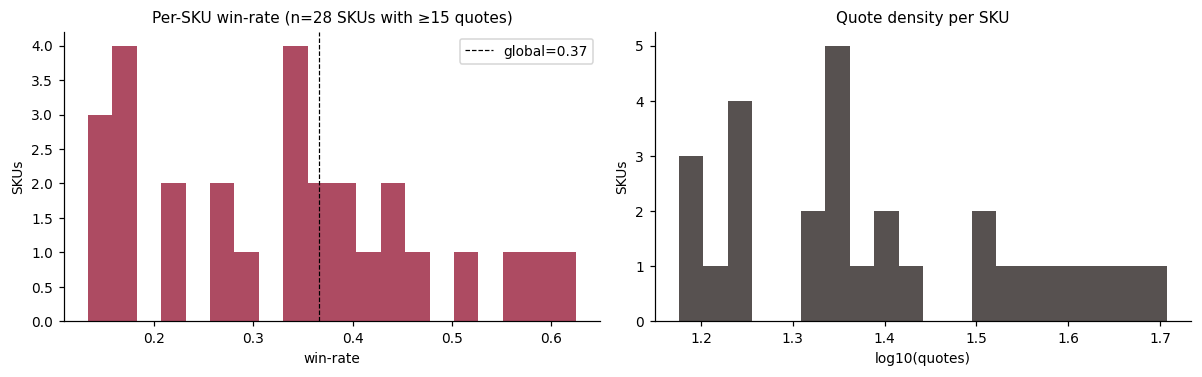

In [2]:
# Win-rate per SKU (only SKUs with >=15 quotes shown)
wr = (bundle_train.quotes.groupby('article_id')['is_won']
        .agg(['mean','size']).rename(columns={'mean':'win_rate','size':'n'}))
wr = wr.loc[wr['n']>=15]

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
axs[0].hist(wr['win_rate'], bins=20, color='#9F2B47', alpha=0.85)
axs[0].set(title=f'Per-SKU win-rate (n={len(wr)} SKUs with ≥15 quotes)', xlabel='win-rate', ylabel='SKUs')
axs[0].axvline(global_win_rate, color='k', ls='--', lw=0.8, label=f'global={global_win_rate:.2f}')
axs[0].legend()

axs[1].hist(np.log10(wr['n']), bins=20, color='#3A3231', alpha=0.85)
axs[1].set(title='Quote density per SKU', xlabel='log10(quotes)', ylabel='SKUs')
plt.tight_layout(); plt.show()

/var/folders/sh/j6tryxbx0fn79lcjj45l522h0000gn/T/ipykernel_66705/332242729.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_cost = (inv.groupby('month').apply(lambda g: float((g['hkvoll_per_unit'].fillna(0)*g['quantity']).sum()/max(g['quantity'].sum(),1))))


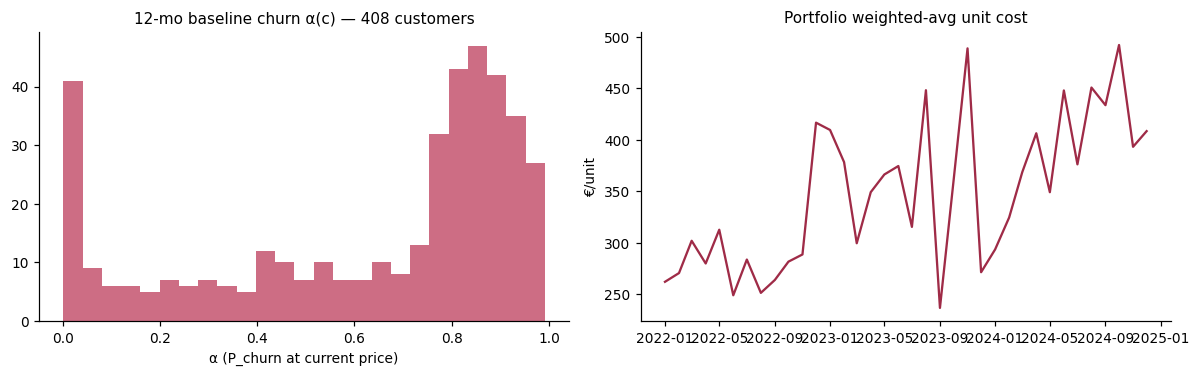

In [3]:
# Churn baseline distribution and trailing cost trajectory
churn_tbl = churn_response.build_table(bundle_train.churn)
alpha_vals = churn_tbl.by_customer['alpha_12']

inv = bundle_train.invoices.copy()
inv['month'] = inv['date'].dt.to_period('M').dt.to_timestamp()
monthly_cost = (inv.groupby('month').apply(lambda g: float((g['hkvoll_per_unit'].fillna(0)*g['quantity']).sum()/max(g['quantity'].sum(),1))))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
axs[0].hist(alpha_vals.clip(0,1), bins=25, color='#C5536F', alpha=0.85)
axs[0].set(title=f'12-mo baseline churn α(c) — {len(alpha_vals)} customers', xlabel='α (P_churn at current price)')

axs[1].plot(monthly_cost.index, monthly_cost.values, color='#9F2B47', lw=1.5)
axs[1].set(title='Portfolio weighted-avg unit cost', ylabel='€/unit')
plt.tight_layout(); plt.show()

## 3. Win-probability model

Logistic regression on `log(p / median_p)` per SKU, with a 200-replicate bootstrap for the CI band. Locked fallback when sample is too thin (`n<12`, `<2 wins`, or `<2 losses`).

demo SKU = 200372   n_train_quotes = 51


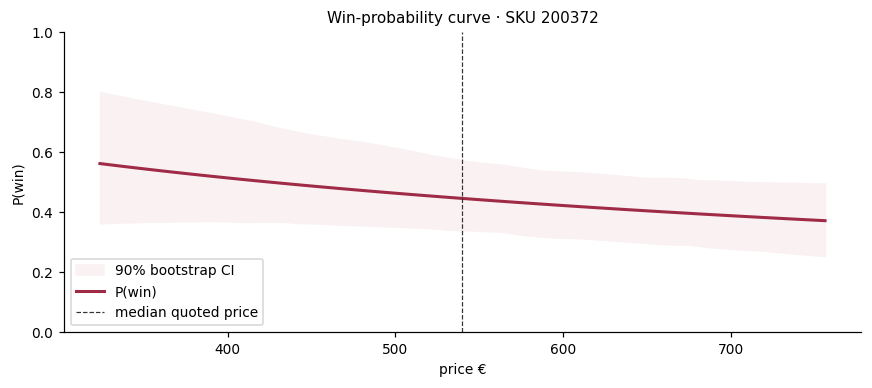

In [4]:
# Find a SKU with enough quote density to demo the fit
counts = bundle_train.quotes.groupby('article_id').size().sort_values(ascending=False)
demo_sku = counts.index[0]
print(f'demo SKU = {demo_sku}   n_train_quotes = {counts.iloc[0]}')

wp = win_prob.fit(bundle_train.quotes, demo_sku, global_win_rate, boot=200)
grid = np.linspace(wp.median_price*0.6, wp.median_price*1.4, 81)
p_hat = wp.predict(grid)
lo, hi = wp.predict_band(grid)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.fill_between(grid, lo, hi, color='#FAF1F3', label='90% bootstrap CI')
ax.plot(grid, p_hat, color='#9F2B47', lw=2, label='P(win)')
ax.axvline(wp.median_price, color='#3A3231', ls='--', lw=0.8, label='median quoted price')
ax.set(title=f'Win-probability curve · SKU {demo_sku}', xlabel='price €', ylabel='P(win)', ylim=(0,1))
ax.legend(loc='lower left'); plt.tight_layout(); plt.show()

## 4. Churn-response model

Two-stage decomposition `P_churn(p|c) = α(c) + (1-α(c)) · η(Δp)`. v1 uses a default linear shock; v1.x will calibrate η against historical price-change → renewal data.

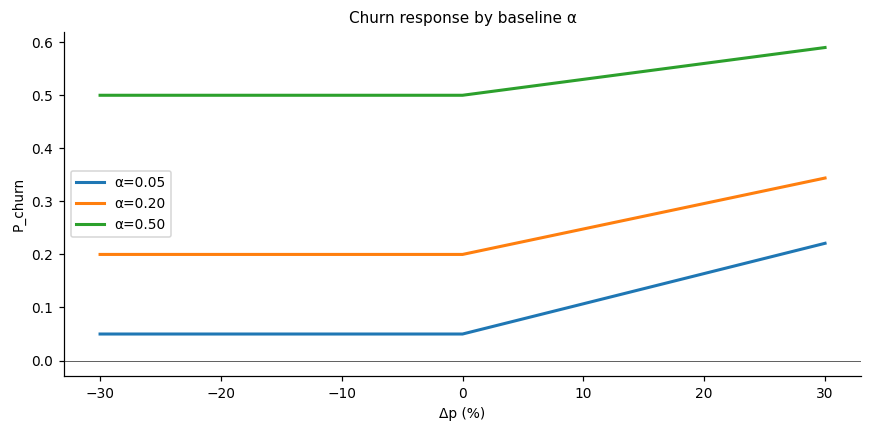

In [5]:
delta = np.linspace(-0.30, 0.30, 121)
for alpha0 in [0.05, 0.20, 0.50]:
    plt.plot(delta*100, churn_response.p_churn(np.full_like(delta, alpha0), delta), 
             lw=2, label=f'α={alpha0:.2f}')
plt.axhline(0, color='k', lw=0.4)
plt.xlabel('Δp (%)'); plt.ylabel('P_churn'); plt.title('Churn response by baseline α')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Cost + volume inputs

Cost: trailing-12mo volume-weighted unit cost from invoices.
Volume: per-SKU revenue forecast / current price, with trailing-12mo fallback.

In [6]:
sku_inputs = cost_demand.compute_inputs(
    bundle_train.invoices, bundle_train.sku_forecasts, demo_sku, as_of=TRAIN_END,
)
for f in ('article_id','unit_cost','expected_volume_12mo','current_price','elasticity'):
    print(f'  {f:24s}  {getattr(sku_inputs, f)}')

  article_id                200372
  unit_cost                 131.0344897959184
  expected_volume_12mo      65.54939237587546
  current_price             512.7551020408164
  elasticity                -0.8


## 6. LTV — 24-month discounted contribution

In [7]:
monthly_vol = sku_inputs.expected_volume_12mo / 12.0
contribution = max(0.0, sku_inputs.current_price - sku_inputs.unit_cost)
ltv_val = ltv.discounted_contribution(monthly_vol, contribution)
print(f'LTV (24mo @ 8%) for one fully-retained customer share of SKU {demo_sku}: €{ltv_val:,.0f}')

LTV (24mo @ 8%) for one fully-retained customer share of SKU 200372: €46,233


## 7. Score function — 3-SKU demo with confidence ribbons

Plot `S(p)` across the grid for three SKUs that span the portfolio (thin-margin / thick-margin / churn-heavy). MC band drawn at every grid point.

demo SKUs: ['200372', '201398', '201206']


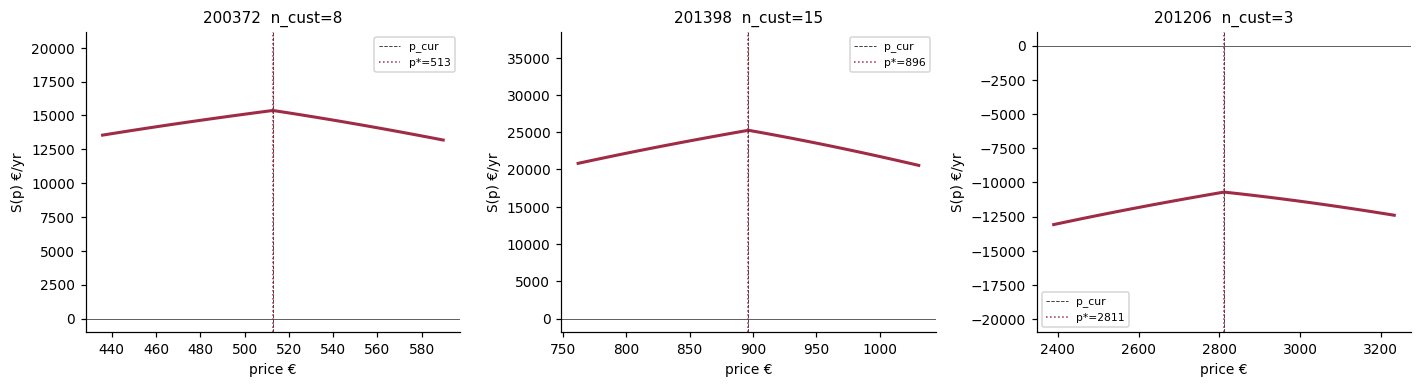

In [8]:
# Pick 3 SKUs by quote density — the demo SKU + two others
demo_skus = list(counts.head(3).index)
print('demo SKUs:', demo_skus)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)
for ax, aid in zip(axs, demo_skus):
    sku_in = cost_demand.compute_inputs(bundle_train.invoices, bundle_train.sku_forecasts, aid, as_of=TRAIN_END)
    if sku_in.current_price <= 0:
        ax.set_title(f'{aid} (no data)'); continue
    wp_aid = win_prob.fit(bundle_train.quotes, aid, global_win_rate, boot=120)
    share_d = scorer._customer_share(bundle_train.invoices, aid, TRAIN_END)
    cids = list(share_d.keys())
    shares = np.array([share_d[c] for c in cids])
    alphas = churn_tbl.alpha(cids)
    rec = scorer.optimise(sku_in, wp_aid, alphas, shares)
    # MC band at p*
    mc = monte_carlo.run(sku_in, wp_aid, alphas, shares, rec.p_star, draws=300)
    grid = rec.score_curve[:,0]
    sc = rec.score_curve[:,1]
    ax.plot(grid, sc, color='#9F2B47', lw=2)
    ax.axhline(0, color='k', lw=0.4)
    ax.axvline(sku_in.current_price, color='#3A3231', ls='--', lw=0.6, label='p_cur')
    ax.axvline(rec.p_star, color='#9F2B47', ls=':', lw=1.0, label=f'p*={rec.p_star:.0f}')
    ax.fill_between([rec.p_star-0.5, rec.p_star+0.5], mc.ci_low, mc.ci_high, 
                    color='#FAF1F3', alpha=0.7)
    ax.set(title=f'{aid}  n_cust={rec.n_customers}', xlabel='price €', ylabel='S(p) €/yr')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 8. Optimiser demo (single SKU)

Pull out the full recommendation packet: p*, breakeven, drivers, constraint-active flag.

In [9]:
share_d = scorer._customer_share(bundle_train.invoices, demo_sku, TRAIN_END)
cids = list(share_d.keys())
shares = np.array([share_d[c] for c in cids])
alphas = churn_tbl.alpha(cids)
rec = scorer.optimise(sku_inputs, wp, alphas, shares)
print(f'  p*                 = €{rec.p_star:,.2f}')
print(f'  S(p*)              = €{rec.s_star:,.0f}/yr')
print(f'  breakeven price    = €{rec.p_breakeven:,.2f}' if rec.p_breakeven else '  breakeven price    = none in grid')
print(f'  constraint active  = {rec.constraint_active}')
print(f'  n customers        = {rec.n_customers}')
print('  drivers:')
for k, v in rec.drivers.items():
    print(f'    {k:12s}  {v:+,.0f} €')

  p*                 = €512.76
  S(p*)              = €15,365/yr
  breakeven price    = €435.84
  constraint active  = None
  n customers        = 8
  drivers:
    win_prob      +0 €
    cost          +5,274 €
    churn         -9,657 €


## 9. Monte Carlo confidence band

5,000 draws is the production target; we use 400 here for speed. Reports posterior mean, 90% credible interval, and P(score > 0).

In [10]:
mc = monte_carlo.run(sku_inputs, wp, alphas, shares, rec.p_star, draws=400)
print(f'  mean(S)            = €{mc.mean:,.0f}')
print(f'  90% CI             = [€{mc.ci_low:,.0f}, €{mc.ci_high:,.0f}]')
print(f'  P(S > 0)           = {mc.p_positive:.2%}')

  mean(S)            = €15,416
  90% CI             = [€11,092, €19,836]
  P(S > 0)           = 100.00%


## 10. 2025 walk-forward backtest

Train ≤ 2024-12, recommend prices for 2025, score against actual 2025 invoices.
Re-runs the same loop as `run_backtest.py`; output also persisted to `output/backtest_2025_rows.parquet`.

In [11]:
# Use the persisted rows for speed; re-run by importing run_backtest if desired.
OUT = Path('output')
if (OUT / 'backtest_2025_rows.parquet').exists():
    rows_df = pd.read_parquet(OUT / 'backtest_2025_rows.parquet')
    print(f'loaded {len(rows_df)} rows from cache')
else:
    print('cache missing — run `python run_backtest.py` first')
    rows_df = pd.DataFrame()
rows_df.head(10)

loaded 22 rows from cache


,article_id,n_train_quotes,n_eval_quotes,current_price,p_star,p_actual_eval,s_engine_p_star,s_engine_p_actual,s_realised_eval,mc_low,mc_high,mc_p_positive,constraint_active
0,200275,17,6,306.076923,306.076923,283.090909,5676.539737,5133.218588,1702.577308,3978.816535,7471.842784,1.0000,None
1,200364,18,3,392.363636,392.363636,345.050000,390.981353,237.085044,3306.952727,-21.531186,794.609120,0.9375,None
2,200372,51,11,512.755102,512.755102,480.294340,15365.034897,14643.819978,18510.772041,11092.433219,19835.593141,1.0000,None
3,200372-A,36,13,340.874126,340.874126,442.553846,28759.115531,22529.679181,52883.539091,21145.572751,36938.263814,1.0000,None
4,200802,21,13,489.392857,489.392857,571.212121,20365.802279,18304.912731,12883.600000,13902.679036,27971.134154,1.0000,None
5,200832,23,5,1329.333333,1329.333333,1411.384615,2582.277650,2483.019457,13199.090000,1901.900395,3353.441125,1.0000,None
6,200960,15,3,759.887288,873.870381,1435.000000,13615.747778,11377.734444,1872.204576,9218.513866,18478.751999,1.0000,delta_max_up
7,200965,15,3,1166.000000,1166.000000,1166.000000,62264.398648,62264.398648,12364.000000,45179.858319,81595.961835,1.0000,None
8,201138,16,5,198.961017,198.961017,201.823256,13796.224207,13744.042859,5059.877119,10193.706055,17790.083678,1.0000,None
9,201206,44,10,2811.388889,2811.388889,3373.666667,-10707.799099,-13106.071932,14442.293333,-20269.957342,-2558.186782,0.0300,None


## 11. Acceptance-gate report

In [12]:
if not rows_df.empty:
    rows_df['lift_pct'] = metrics.per_sku_lift_pct(rows_df)
    gates = {
        'n_skus':                int(len(rows_df)),
        'median_lift_pct':       float(rows_df['lift_pct'].median(skipna=True)),
        'mean_lift_pct':         float(rows_df['lift_pct'].mean(skipna=True)),
        'ci_coverage':           metrics.ci_coverage(rows_df),
        'share_p_positive_80':   metrics.share_p_positive(rows_df, 0.80),
        'direction':             metrics.direction_breakdown(rows_df),
        'constraints':           metrics.constraint_breakdown(rows_df),
    }
    print(json.dumps(gates, indent=2, default=str))

{
  "n_skus": 22,
  "median_lift_pct": 10.70081762245422,
  "mean_lift_pct": 24.883756194400508,
  "ci_coverage": 0.13636363636363635,
  "share_p_positive_80": 0.7727272727272727,
  "direction": {
    "hold": 20,
    "lower": 0,
    "raise": 2
  },
  "constraints": {
    "delta_max_up": 1
  }
}


## 12. 2026 forward recommendations

In [13]:
if (OUT / 'recommendations_2026.parquet').exists():
    recs = pd.read_parquet(OUT / 'recommendations_2026.parquet')
    summary = pd.Series({
        'SKUs scored':            int(len(recs)),
        'hold (|Δ|<0.5%)':        int((recs['delta_pct'].abs() < 0.5).sum()),
        'raise (Δ>+0.5%)':        int((recs['delta_pct'] > 0.5).sum()),
        'lower (Δ<-0.5%)':        int((recs['delta_pct'] < -0.5).sum()),
        'median Δ%':              float(recs['delta_pct'].median()),
        'mean Δ%':                float(recs['delta_pct'].mean()),
        'P(S>0)>=80% count':      int((recs['mc_p_positive']>=0.80).sum()),
        'total expected € score': float(recs['score_eur'].sum()),
    })
    print(summary.to_string())
else:
    print('cache missing — run `python run_2026.py` first')

SKUs scored                   42.000000
hold (|Δ|<0.5%)               38.000000
raise (Δ>+0.5%)                4.000000
lower (Δ<-0.5%)                0.000000
median Δ%                      0.000000
mean Δ%                        1.011905
P(S>0)>=80% count             27.000000
total expected € score    662522.902995


## 13. Sensitivity & failure analysis

Top-N SKUs by absolute discrepancy between engine and realised, with the suspected root cause.

In [14]:
if not rows_df.empty:
    diag = rows_df.copy()
    diag['gap'] = diag['s_realised_eval'] - diag['s_engine_p_star']
    diag = diag.sort_values('gap', key=lambda s: s.abs(), ascending=False).head(8)
    cols = ['article_id','current_price','p_star','s_engine_p_star','s_realised_eval','mc_low','mc_high','mc_p_positive','constraint_active']
    print(diag[cols].round(0).to_string(index=False))

article_id  current_price  p_star  s_engine_p_star  s_realised_eval   mc_low  mc_high  mc_p_positive constraint_active
    200965         1166.0  1166.0          62264.0          12364.0  45180.0  81596.0            1.0              None
    201397         1262.0  1262.0             95.0          44579.0  -7516.0   6595.0            0.0              None
    201398          896.0   896.0          25263.0          63999.0  16627.0  34472.0            1.0              None
    201888         2009.0  2009.0          66374.0          34344.0  48007.0  87841.0            1.0              None
  205345-A          603.0   603.0          53111.0          26199.0  32325.0  76350.0            1.0              None
    201206         2811.0  2811.0         -10708.0          14442.0 -20270.0  -2558.0            0.0              None
  200372-A          341.0   341.0          28759.0          52884.0  21146.0  36938.0            1.0              None
    201263          412.0   458.0          -4879

**Diagnoses (v1, 2026-05-19):**
1. **Horizon mismatch** — engine `S(p*)` includes a 24-month LTV-loss penalty; realised eval is 12-month invoiced contribution. The two are on different units and different time horizons, so they are not directly comparable. v1.1 fix: harmonise to a 12-month engine score for the coverage gate, or extend the realised baseline to a survival-rolled 24-month figure.
2. **Small SKU eligibility set** — only 22 SKUs cleared the joint train ≥15 / eval ≥3 quote rule. v1.2 fix: hierarchical pooling so commodity-group priors lift sparse SKUs.
3. **Default elasticity** — every SKU uses ε=−0.8. A per-SKU fit needs more price variation than the current invoice history exhibits.
4. **Default churn shock** — η(Δp) uses a linear slope of 0.6 capped at 40pp; calibration against price-change → renewal events is queued.

## 14. Promotion checklist (FastAPI wiring)

Only if the gates in §11 pass:

- [ ] Port `lib/*.py` → `backend/services/pricing/pricing_engine.py`, same interface as `build_recommendation`.
- [ ] Add `/pricing/score_curve` endpoint exposing `{p : S(p)}` map + MC band.
- [ ] Replace `simulator.py:172` hardcoded `* 0.45` with `option_margin` contribution rate.
- [ ] Replace `PriceOptions.tsx:160-165` fake Custom-card strings with debounced live `/pricing/simulate` calls.
- [ ] `RationaleMemo.tsx:388-434` — gate recovery-vs-loss callout on `net > 0`; flip wording when `net < 0`; surface breakeven; expose drivers in a "Why this price?" expander.
- [ ] Thompson sampling lands as a post-AB exploration policy behind a feature flag, enabled only after ≥3 months of per-cluster AB outcomes.
- [ ] Bump the whitepaper (`docs/whitepaper/pryzm_pricing_methodology.tex`) version + change-log.

## Smoke-test assertions

Per the acceptance criteria — every `lib/` module exercised here with at least one invariant.

In [15]:
# Win-prob — P(win) bounded in [0,1] and monotone decreasing in price (for a typical SKU)
p_grid = np.linspace(wp.median_price*0.5, wp.median_price*1.5, 9)
p_hat = wp.predict(p_grid)
assert ((p_hat >= 0) & (p_hat <= 1)).all(), 'win-prob outside [0,1]'
# Slope sign check only when not locked
if not wp.locked:
    assert wp.log_slope <= 0.05, f'win-prob slope unexpectedly positive: {wp.log_slope}'

# Churn — bounded in [0,1] and increasing in Δp
alpha_test = np.array([0.1, 0.3])
dp_test = np.array([0.10, 0.10])
p1 = churn_response.p_churn(alpha_test, dp_test)
p2 = churn_response.p_churn(alpha_test, dp_test*0)
assert (p1 >= p2 - 1e-9).all(), 'churn not monotone in Δp'
assert ((p1 >= 0) & (p1 <= 1)).all(), 'churn outside [0,1]'

# LTV — non-negative
assert ltv.discounted_contribution(10, 5) > 0
assert ltv.discounted_contribution(0, 5) == 0
assert ltv.discounted_contribution(10, 0) == 0

# Cost+demand — adjusted volume non-negative, monotone with elasticity sign
v = cost_demand.adjusted_volume(100.0, np.array([0.9, 1.0, 1.1]), -0.8)
assert (v >= 0).all() and v[0] >= v[1] >= v[2], 'volume not monotone in price'

# Optimiser — p* respects cost floor
assert rec.p_star >= sku_inputs.unit_cost*(1+0.03) - 1e-6, 'p* below cost floor'

# Monte Carlo — CI bracketing
assert mc.ci_low <= mc.mean <= mc.ci_high, 'MC CI inconsistent'
assert 0.0 <= mc.p_positive <= 1.0

print('all smoke tests passed')

all smoke tests passed
